This notebook plots the solutions. You can actually plot the progress while the solver is running to see if it makes sense.

Various imports:

In [1]:
%load_ext autoreload
%autoreload 2
# add path to code
import sys
sys.path.insert(0, '../source')
import numpy as np
from matplotlib.tri import Triangulation
from matplotlib import colors
import matplotlib.pyplot as plt
import matplotlib as mpl
import topotoolbox as tt3
from params import rho_w,g
from load_lakes import lake_inventory
import json
from shapely import Point

In [2]:
# get dem for topotoolbox plotting
dem = tt3.read_tif('thw_dem_plotting.tif')
fd = tt3.FlowObject(dem)
s   = tt3.StreamObject(fd,threshold=2000,units='pixels')

# Set default major tick width for x-axis
mpl.rcParams['xtick.major.width'] = 2
mpl.rcParams['xtick.major.size'] = 4


# Set default major tick width for y-axis
mpl.rcParams['ytick.major.width'] = 2
mpl.rcParams['ytick.major.size'] = 4

In [9]:
#choose which results to load
results_name = '../results/Thw_124_reffine'
# results_name = '../results/Thw_124_pump1fine'
t = np.load(results_name+'/t.npy')
nodes_x = np.load(results_name+'/nodes_x.npy')/1e3
nodes_y = np.load(results_name+'/nodes_y.npy')/1e3
dofmap = np.load(results_name+'/dofmap.npy')
lake_bdry = np.load(results_name+'/lake_bdry.npy')
triang = Triangulation(nodes_x,nodes_y,dofmap)

# load results
N = np.load(results_name+'/N.npy')
b = np.load(results_name+'/b.npy')
qx = np.load(results_name+'/qx.npy')
qy = np.load(results_name+'/qy.npy')
outflow_dofs = np.load(results_name+'/outflow_dofs.npy')

boundary_coords = np.load(results_name+'/boundary_coords.npy')/1e3
outflow_coords = np.load(results_name+'/outflow_coords.npy')/1e3
inflow_coords = np.load(results_name+'/inflow_coords.npy')/1e3


# get water flow speed
q_m = np.sqrt(qx**2+qy**2)

with open(results_name+"/model_config.json", "r") as f:
    model_config = json.load(f)

neighbors = ['Thw_142', 'Thw_124', 'Thw_170', 'Thw_70'] #model_config['neighbors']
lake_name = model_config['lake_name']
outflow_on = model_config['outflow_on']
storage_on = model_config['storage_on']
N_bdry = model_config['N_bdry']
x_min = model_config['x_min']/1e3
x_max = model_config['x_max']/1e3
y_min = model_config['y_min']/1e3
y_max = model_config['y_max']/1e3

# pump site
x_p = model_config['x_p']/1e3
y_p = model_config['y_p']/1e3


outline = lake_inventory.loc[lake_inventory['name']==lake_name]
# # if we want to look at another lake, 
# # can define new lake boundary like this
# outline_ = lake_inventory.loc[lake_inventory['name']=="Thw_124"]
# lake_bdry_ = np.zeros(nodes_x.size)
# for j in range(lake_bdry_.size):
#     point = Point(nodes_x[j],nodes_y[j])
#     lake_bdry_[j] = outline_.geometry.contains(point).iloc[0]
# get mean of N over the lake and max of q not over the lake

N_mean = np.zeros(t.size)
j_max=0
for j in range(t.size):
    if np.max(q_m[j,:]>1e-10):
     
        N_j = N[j,:]

        N_mean[j] = np.mean(N_j[lake_bdry>1e-3])

        j_max+=1 

j_max -= 1

# storage in the lake, assuming water density 1000 kg/m^3
b_L = -(N_mean-N_mean[0])/(rho_w*g)

In [4]:
#choose which results to load
results_ref = '../results/Thw_124_reffine'
t_ref = np.load(results_ref+'/t.npy')

# load results
N_ref = np.load(results_ref+'/N.npy')
lake_bdry_ref = np.load(results_ref+'/lake_bdry.npy')



N_mean_ref = np.zeros(t_ref.size)
for j in range(t_ref.size):
     
    N_j = N_ref[j,:]

    N_mean_ref[j] = np.mean(N_j[lake_bdry_ref>1e-3])


# storage in the lake, assuming water density 1000 kg/m^3
b_L_ref = -(N_mean_ref-N_mean_ref[0])/(rho_w*g)

j_0 = np.argmin(np.abs(t_ref/86400-8*365))
j_00 = np.argmin(np.abs(t_ref/86400-3*365))

In [5]:
results_2 = '../results/Thw_124_pump2fine'
t_2 = np.load(results_2+'/t.npy')

# load results
N_2 = np.load(results_2+'/N.npy')
lake_bdry_2 = np.load(results_2+'/lake_bdry.npy')



N_mean_2 = np.zeros(t_2.size)
j_max_2 = 0
for j in range(t_2.size):
    if np.max(np.abs(N_2[j,:]))>1e-10:
     
        N_j = N_2[j,:]

        N_mean_2[j] = np.mean(N_j[lake_bdry_2>1e-3])
        j_max_2 += 1

j_max_2 -= 1


# storage in the lake, assuming water density 1000 kg/m^3
b_L_2 = -(N_mean_2-N_mean_2[0])/(rho_w*g)

with open(results_2+"/model_config.json", "r") as f:
    model_config2 = json.load(f)

x_p2 = model_config2['x_p']/1e3
y_p2 = model_config2['y_p']/1e3

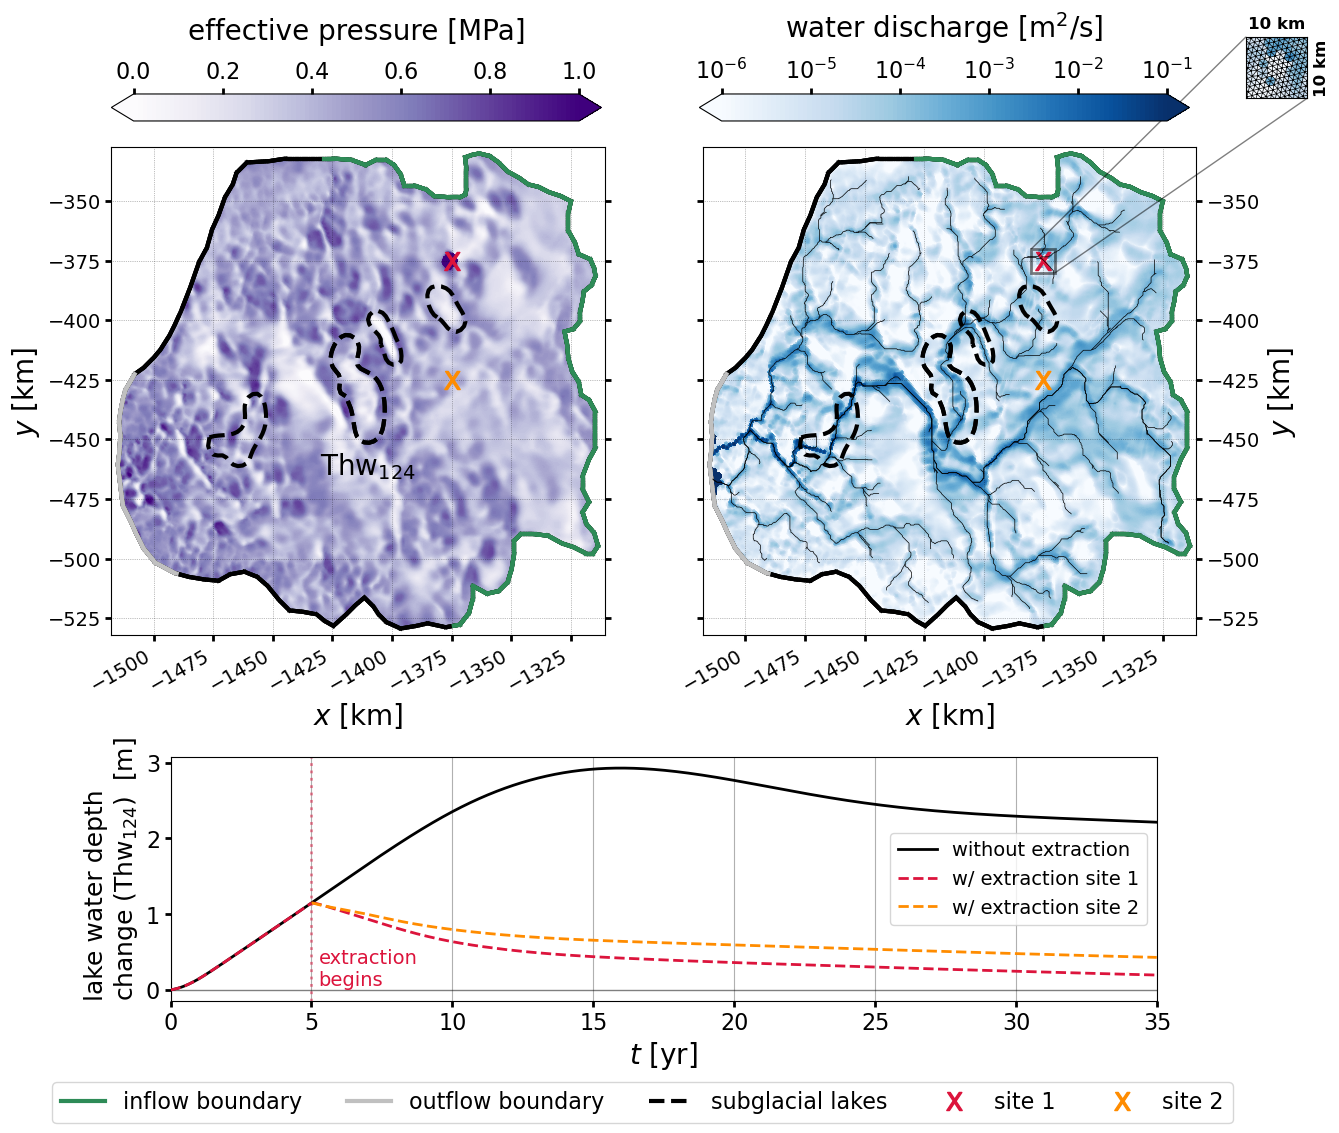

In [6]:
# choose to plot a single timestep OR a sequence to make a movie
ind = [j_max]               # plot a single time step
# ind = np.arange(1,j_max,1) # plot every time step for saving a movie

# make clean movie directory
# !rm -rf {results_name}/movie
# !mkdir {results_name}/movie

j=0

if len(ind)>1:
# use agg backend for saving pngs
    mpl.use('agg')
else:
    %matplotlib inline

qlim2 = -1 
qlim1 = -6 

t_scale = 1.0 # 1 for years, 365 for days
if int(t_scale)==365:
    t_str = 'd' 
elif int(t_scale)==1:
    t_str = 'yr'

res_lim = 2

for i in ind:
    print('saved image '+str(j+1)+' out of '+str(len(ind))+' \r',end='')
    
    fig = plt.figure(figsize=(14,12))
    

    ax1 = plt.subplot(121)
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    N_i = N[i]
    for coords in boundary_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=3)
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3)
    
    for coords in inflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3)
    
    p1 = plt.tricontourf(triang,N_i/1e6,levels=np.linspace(0,1,100),cmap='Purples',extend='both')
    outline.plot(edgecolor='k',facecolor='none',linestyle='--',ax=plt.gca(),linewidth=3,zorder=105)
    for name in neighbors:
        outline_nbr = lake_inventory.loc[lake_inventory['name']==name]
        outline_nbr.plot(edgecolor='k',linestyle='--',facecolor='none',ax=plt.gca(),linewidth=3,zorder=105)

    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.plot([x_p],[y_p],marker=r'$\mathrm{X}$',markersize=13,color='crimson',linewidth=0)#,label='extraction site')
    plt.plot([x_p2],[y_p2],marker=r'$\mathrm{X}$',markersize=13,color='darkorange',linewidth=0)#,label='extraction site 2')
    plt.setp(ax1.get_xticklabels(), rotation=30, horizontalalignment='right')
    plt.gca().tick_params(axis='y', which='both', labelright=False, right=True)
    cbar_ax = fig.add_axes([0.125, 0.72, 0.35, 0.0225])
    cbar = plt.colorbar(p1,orientation='horizontal',ticks=np.linspace(0,1,6),cax=cbar_ax)
    cbar.set_label(r'effective pressure [MPa]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    ax1.annotate(r'Thw$_{124}$',xy=(-1430,-465),fontsize=20,color='k',zorder=1000)

    ax3 = plt.subplot(122)
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    q_i = q_m[i]
    for coords in boundary_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=3)
    
    flag_0 = 0         
            
    for coords in inflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            if flag_0 == 0:
                plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3,label=r'inflow boundary')
                flag_0 += 1
            else:
                plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3)
              
    flag_0 = 0
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            if flag_0 == 0:
                plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3,label=r'outflow boundary')
                flag_0 += 1
            else:
                plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3)
  
            
    p2 = plt.tricontourf(triang,q_i,cmap='Blues',extend='both',norm=colors.LogNorm(),levels=np.logspace(qlim1,qlim2,100))
    outline.plot(edgecolor='k',facecolor='none',linestyle='--',ax=plt.gca(),linewidth=3,zorder=105)
    for name in neighbors:
        outline_nbr = lake_inventory.loc[lake_inventory['name']==name]
        outline_nbr.plot(edgecolor='k',facecolor='none',linestyle='--',ax=plt.gca(),linewidth=3,zorder=105)
        
    plt.plot([np.inf],[np.inf],'k--',linewidth=3,label=r'subglacial lakes')
    plt.plot([x_p],[y_p],marker=r'$\mathrm{X}$',markersize=13,color='crimson',linewidth=0,label='site 1')
    plt.plot([x_p2],[y_p2],marker=r'$\mathrm{X}$',markersize=13,color='darkorange',linewidth=0,label='site 2')
    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.gca().yaxis.set_label_position("right")
    plt.gca().yaxis.tick_right()
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.gca().tick_params(axis='y', which='both', labelleft=False, left=True)
    plt.legend(fontsize=16,loc=(-1.32,-1.0),ncol=5)
    #------- stream plot ------------
    xtix = ax3.get_xticks()
    ytix = ax3.get_yticks()
    xlim = ax3.get_xlim()
    ylim = ax3.get_ylim()

    dem.plot(ax3,cmap="terrain",alpha=0) 
    (s.klargestconncomps(1)).plot(ax=ax3,color='k',linewidth=0.5)
    (s.klargestconncomps(1).trunk()).plot(ax=ax3,color='k',linewidth=0.5)
    ax3.invert_yaxis()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    ax3.tick_params(axis='y', which='both', labelleft=False, left=True)
    ax3.set_xticks(xtix)
    ax3.set_yticks(ytix)
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    plt.setp(ax3.get_xticklabels(), rotation=30, horizontalalignment='right')

    #-------------------------------
    cbar_ax = fig.add_axes([0.545, 0.72, 0.35, 0.0225])
    cbar = plt.colorbar(p2,cax=cbar_ax,orientation='horizontal',ticks=np.logspace(qlim1,qlim2,1+int(np.abs(qlim2-qlim1))))#,format='%.0e')
    cbar.set_label(r'water discharge [m$^2/$s]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    ax_in1 = ax1.inset_axes([0.12, -0.75, 2, 0.5])
    
    # FIX THIS!!!
    t00 = 3
    ax_in1.plot((t_ref[j_00:j_0+i])*t_scale/3.154e7-t00,b_L_ref[j_00:j_0+i]-b_L_ref[j_00],color='k',linestyle='-',linewidth=2,zorder=100,label=r'without extraction')
    ax_in1.plot((t_ref[j_00:j_0])*t_scale/3.154e7-t00,b_L_ref[j_00:j_0]-b_L_ref[j_00],color='crimson',linestyle='--',linewidth=2,zorder=101)
    ax_in1.plot((t[1:i]+t_ref[j_0])*t_scale/3.154e7-t00,b_L[1:i]+b_L_ref[j_0]-b_L_ref[j_00],color='crimson',linestyle='--',linewidth=2,zorder=100,label='w/ extraction site 1')
    ii = j_max_2
    ax_in1.plot((t_2[1:ii]+t_ref[j_0])*t_scale/3.154e7-t00,b_L_2[1:ii]+b_L_ref[j_0]-b_L_ref[j_00],color='darkorange',linestyle='--',linewidth=2,zorder=100,label='w/ extraction site 2')
    ax_in1.annotate('extraction\nbegins',xy=(5.25,0.05),fontsize=14,color='crimson')
    ax_in1.set_ylabel('lake water depth \n'+r'change (Thw$_{124}$) $\;$[m]',fontsize=18,color='k',loc='bottom',zorder=99)
    ax_in1.tick_params(axis='y', colors="k")
    ax_in1.set_xlim(0,35)
    ax_in1.grid(axis='x')
    ax_in1.set_xlabel(r'$t$ [yr]',fontsize=20)
    ax_in1.tick_params(axis='both', labelsize=16)
    ax_in1.axvline(x=t_ref[j_0]/3.154e7-t00,linestyle=':',color='crimson',linewidth=2,alpha=0.5)
    ax_in1.legend(fontsize=14,loc='center right')
    ax_in1.axhline(y=0,xmin=0,xmax=1,color='k',linewidth=1,alpha=0.5)

    axins = ax3.inset_axes([1.1, 1.1, 0.125, 0.125])
    axins.triplot(triang,color='k',linewidth=0.5,zorder=100)
    axins.tricontourf(triang,q_i,cmap='Blues',extend='both',norm=colors.LogNorm(),levels=np.logspace(qlim1,qlim2,100))
    x0 = float(outline.centroid.x.iloc[0])*1e3
    y0 = float(outline.centroid.y.iloc[0])*1e3
    x_ins = x_p #x0 + 50e3
    y_ins = y_p #y0 + 50e3
    axins.set_xlim(x_ins-5,x_ins+5)
    axins.set_ylim(y_ins-5,y_ins+5)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title(r'10 km',fontsize=12,fontweight='bold')
    axins.set_ylabel(r'10 km',fontsize=12,fontweight='bold',labelpad=5)
    axins.yaxis.set_label_position("right")
    ax3.indicate_inset_zoom(axins, edgecolor="k",linewidth=2,zorder=300)

    if len(ind)>1:
        plt.savefig('{}/movie/movie_'.format(results_name)+str(j),bbox_inches='tight')
    if len(ind)==1:
        plt.savefig('thw_fig',bbox_inches='tight')
        plt.show()
    plt.close()
    j+=1

In [7]:
# check value of far-field effective pressure if simulation runs
# for longer than a year... is similar to outlet b.c. value? 
outflow_inds = np.ones(N_i.size)
outflow_inds[outflow_dofs]=0
time_frame = 365
if j_max > time_frame:
    N_far = np.zeros(time_frame)

    for j in range(time_frame):
        N_j = N[j+j_max-time_frame,:]
        N_far[j] = np.mean(N_j[(lake_bdry<1e-2)&(outflow_inds>1e-8)])
    print(f'N_far = {N_far.mean()/1e6:.2f} MPa')

N_far = 0.47 MPa


In [8]:
#choose which results to load
results_ref = '../results/Thw_124_reffine'
t_ref = np.load(results_ref+'/t.npy')

# load results
N_ref = np.load(results_ref+'/N.npy')
lake_bdry_ref = np.load(results_ref+'/lake_bdry.npy')



N_mean_ref = np.zeros(t_ref.size)
for j in range(t_ref.size):
     
    N_j = N_ref[j,:]

    N_mean_ref[j] = np.mean(N_j[lake_bdry_ref>1e-3])


# storage in the lake, assuming water density 1000 kg/m^3
b_L_ref = -(N_mean_ref-N_mean_ref[0])/(rho_w*g)

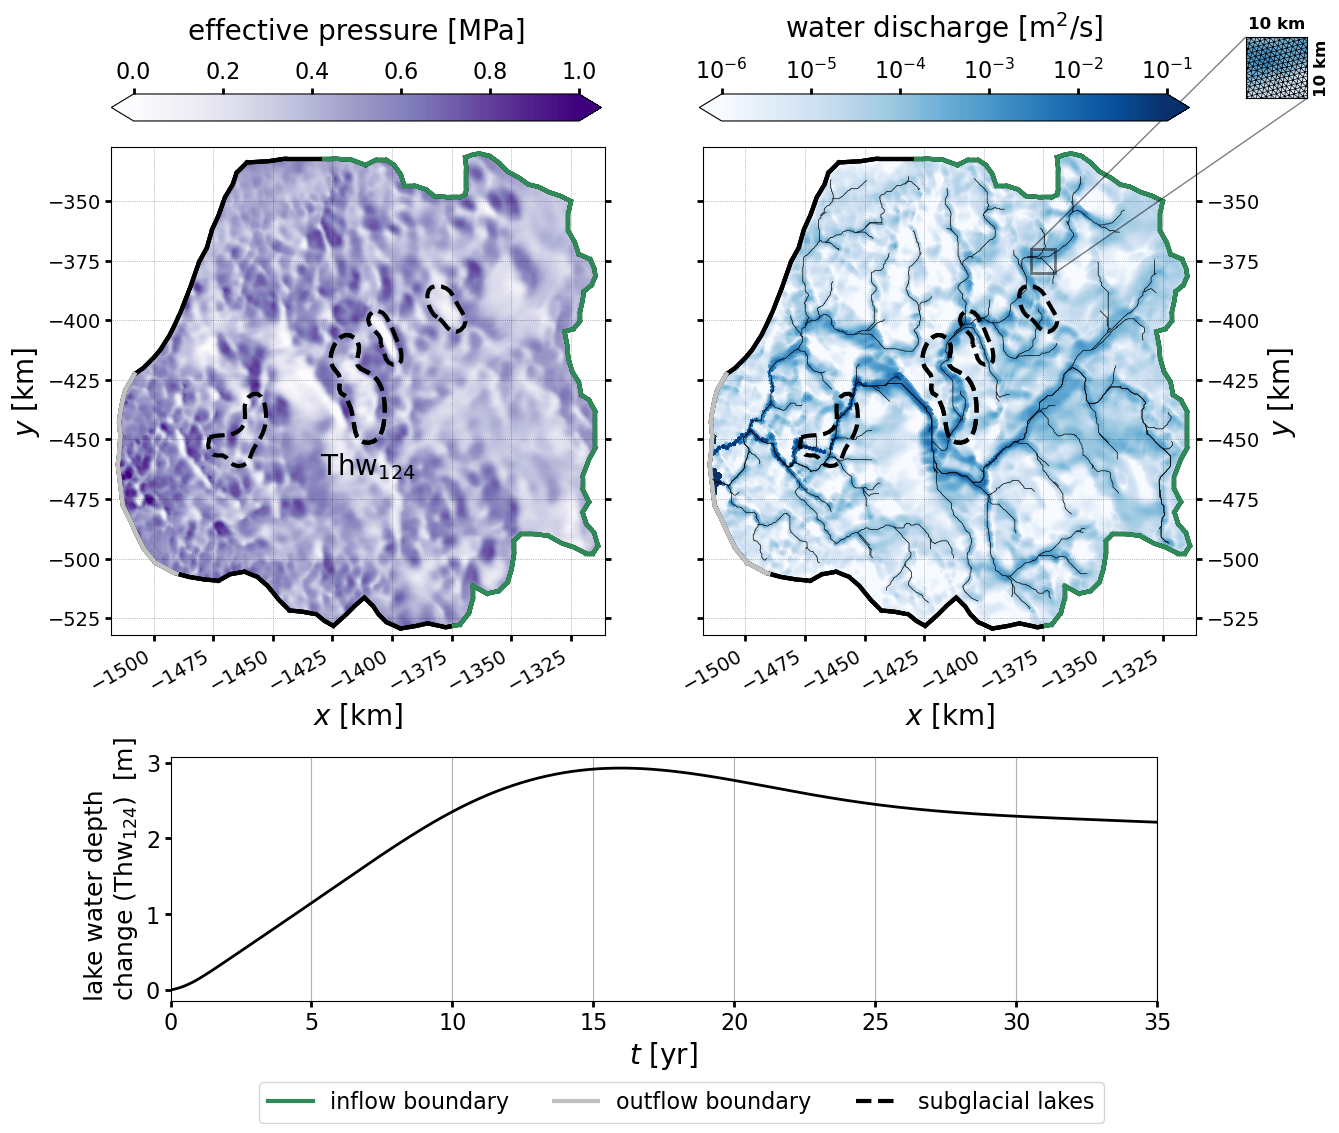

In [14]:
# choose to plot a single timestep OR a sequence to make a movie
ind = [j_max]               # plot a single time step
# ind = np.arange(1,j_max,1) # plot every time step for saving a movie

# make clean movie directory
# !rm -rf {results_name}/movie
# !mkdir {results_name}/movie

j=0

if len(ind)>1:
# use agg backend for saving pngs
    mpl.use('agg')
else:
    %matplotlib inline

qlim2 = -1 
qlim1 = -6 

t_scale = 1.0 # 1 for years, 365 for days
if int(t_scale)==365:
    t_str = 'd' 
elif int(t_scale)==1:
    t_str = 'yr'

res_lim = 2

for i in ind:
    print('saved image '+str(j+1)+' out of '+str(len(ind))+' \r',end='')
    
    fig = plt.figure(figsize=(14,12))
    

    ax1 = plt.subplot(121)
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    N_i = N[i]
    for coords in boundary_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=3)
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3)
    
    for coords in inflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3)
    
    p1 = plt.tricontourf(triang,N_i/1e6,levels=np.linspace(0,1,100),cmap='Purples',extend='both')
    outline.plot(edgecolor='k',facecolor='none',linestyle='--',ax=plt.gca(),linewidth=3,zorder=105)
    for name in neighbors:
        outline_nbr = lake_inventory.loc[lake_inventory['name']==name]
        outline_nbr.plot(edgecolor='k',linestyle='--',facecolor='none',ax=plt.gca(),linewidth=3,zorder=105)

    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    # plt.plot([x_p],[y_p],marker=r'$\mathrm{X}$',markersize=13,color='crimson',linewidth=0)#,label='extraction site')
    # plt.plot([x_p2],[y_p2],marker=r'$\mathrm{X}$',markersize=13,color='darkorange',linewidth=0)#,label='extraction site 2')
    plt.setp(ax1.get_xticklabels(), rotation=30, horizontalalignment='right')
    plt.gca().tick_params(axis='y', which='both', labelright=False, right=True)
    cbar_ax = fig.add_axes([0.125, 0.72, 0.35, 0.0225])
    cbar = plt.colorbar(p1,orientation='horizontal',ticks=np.linspace(0,1,6),cax=cbar_ax)
    cbar.set_label(r'effective pressure [MPa]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    ax1.annotate(r'Thw$_{124}$',xy=(-1430,-465),fontsize=20,color='k',zorder=1000)

    ax3 = plt.subplot(122)
    plt.grid(alpha=0.5,linestyle=':',color='k',linewidth=0.5)
    q_i = q_m[i]
    for coords in boundary_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            plt.plot(coords[:, 0], coords[:, 1], color='black',linewidth=3)
    
    flag_0 = 0         
            
    for coords in inflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            if flag_0 == 0:
                plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3,label=r'inflow boundary')
                flag_0 += 1
            else:
                plt.plot(coords[:, 0], coords[:, 1], color='seagreen',linewidth=3)
              
    flag_0 = 0
    for coords in outflow_coords:
        if np.abs(coords[1,0]-coords[0,0])< res_lim:
            if flag_0 == 0:
                plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3,label=r'outflow boundary')
                flag_0 += 1
            else:
                plt.plot(coords[:, 0], coords[:, 1], color='silver',linewidth=3)
  
            
    p2 = plt.tricontourf(triang,q_i,cmap='Blues',extend='both',norm=colors.LogNorm(),levels=np.logspace(qlim1,qlim2,100))
    outline.plot(edgecolor='k',facecolor='none',linestyle='--',ax=plt.gca(),linewidth=3,zorder=105)
    for name in neighbors:
        outline_nbr = lake_inventory.loc[lake_inventory['name']==name]
        outline_nbr.plot(edgecolor='k',facecolor='none',linestyle='--',ax=plt.gca(),linewidth=3,zorder=105)
        
    plt.plot([np.inf],[np.inf],'k--',linewidth=3,label=r'subglacial lakes')
    # plt.plot([x_p],[y_p],marker=r'$\mathrm{X}$',markersize=13,color='crimson',linewidth=0,label='site 1')
    # plt.plot([x_p2],[y_p2],marker=r'$\mathrm{X}$',markersize=13,color='darkorange',linewidth=0,label='site 2')
    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r'$x$ [km]',fontsize=20)
    plt.gca().yaxis.set_label_position("right")
    plt.gca().yaxis.tick_right()
    plt.ylabel(r'$y$ [km]',fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.gca().tick_params(axis='y', which='both', labelleft=False, left=True)
    plt.legend(fontsize=16,loc=(-0.9,-1.0),ncol=3)
    #------- stream plot ------------
    xtix = ax3.get_xticks()
    ytix = ax3.get_yticks()
    xlim = ax3.get_xlim()
    ylim = ax3.get_ylim()

    dem.plot(ax3,cmap="terrain",alpha=0) 
    (s.klargestconncomps(1)).plot(ax=ax3,color='k',linewidth=0.5)
    (s.klargestconncomps(1).trunk()).plot(ax=ax3,color='k',linewidth=0.5)
    ax3.invert_yaxis()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    ax3.tick_params(axis='y', which='both', labelleft=False, left=True)
    ax3.set_xticks(xtix)
    ax3.set_yticks(ytix)
    ax3.set_xlim(xlim)
    ax3.set_ylim(ylim)
    plt.setp(ax3.get_xticklabels(), rotation=30, horizontalalignment='right')

    #-------------------------------
    cbar_ax = fig.add_axes([0.545, 0.72, 0.35, 0.0225])
    cbar = plt.colorbar(p2,cax=cbar_ax,orientation='horizontal',ticks=np.logspace(qlim1,qlim2,1+int(np.abs(qlim2-qlim1))))#,format='%.0e')
    cbar.set_label(r'water discharge [m$^2/$s]',fontsize=20,labelpad=15)
    cbar.ax.tick_params(labelsize=16)
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')
    
    ax_in1 = ax1.inset_axes([0.12, -0.75, 2, 0.5])
    
    # FIX THIS!!!
    t00 = 3
    ax_in1.plot((t_ref[j_00:j_0+i])*t_scale/3.154e7-t00,b_L_ref[j_00:j_0+i]-b_L_ref[j_00],color='k',linestyle='-',linewidth=2,zorder=100,label=r'without extraction')
    # ax_in1.plot((t_ref[j_00:j_0])*t_scale/3.154e7-t00,b_L_ref[j_00:j_0]-b_L_ref[j_00],color='crimson',linestyle='--',linewidth=2,zorder=101)
    # ax_in1.plot((t[1:i]+t_ref[j_0])*t_scale/3.154e7-t00,b_L[1:i]+b_L_ref[j_0]-b_L_ref[j_00],color='crimson',linestyle='--',linewidth=2,zorder=100,label='w/ extraction site 1')
    ii = j_max_2
    # ax_in1.plot((t_2[1:ii]+t_ref[j_0])*t_scale/3.154e7-t00,b_L_2[1:ii]+b_L_ref[j_0]-b_L_ref[j_00],color='darkorange',linestyle='--',linewidth=2,zorder=100,label='w/ extraction site 2')
    # ax_in1.annotate('extraction\nbegins',xy=(5.25,0.05),fontsize=14,color='crimson')
    ax_in1.set_ylabel('lake water depth \n'+r'change (Thw$_{124}$) $\;$[m]',fontsize=18,color='k',loc='bottom',zorder=99)
    ax_in1.tick_params(axis='y', colors="k")
    ax_in1.set_xlim(0,35)
    ax_in1.grid(axis='x')
    ax_in1.set_xlabel(r'$t$ [yr]',fontsize=20)
    ax_in1.tick_params(axis='both', labelsize=16)
    # ax_in1.axvline(x=t_ref[j_0]/3.154e7-t00,linestyle=':',color='crimson',linewidth=2,alpha=0.5)
    # ax_in1.legend(fontsize=14,loc='center right')
    # ax_in1.axhline(y=0,xmin=0,xmax=1,color='k',linewidth=1,alpha=0.5)

    axins = ax3.inset_axes([1.1, 1.1, 0.125, 0.125])
    axins.triplot(triang,color='k',linewidth=0.5,zorder=100)
    axins.tricontourf(triang,q_i,cmap='Blues',extend='both',norm=colors.LogNorm(),levels=np.logspace(qlim1,qlim2,100))
    x0 = float(outline.centroid.x.iloc[0])*1e3
    y0 = float(outline.centroid.y.iloc[0])*1e3
    x_ins = x_p #x0 + 50e3
    y_ins = y_p #y0 + 50e3
    axins.set_xlim(x_ins-5,x_ins+5)
    axins.set_ylim(y_ins-5,y_ins+5)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title(r'10 km',fontsize=12,fontweight='bold')
    axins.set_ylabel(r'10 km',fontsize=12,fontweight='bold',labelpad=5)
    axins.yaxis.set_label_position("right")
    ax3.indicate_inset_zoom(axins, edgecolor="k",linewidth=2,zorder=300)

    if len(ind)>1:
        plt.savefig('{}/movie/movie_'.format(results_name)+str(j),bbox_inches='tight')
    if len(ind)==1:
        plt.savefig('thw_fig_alt',bbox_inches='tight')
        plt.show()
    plt.close()
    j+=1